# Sustainabilty models

In [ ]:
# ----------------------------
# IMPORTS + CONFIG
# ----------------------------

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import plot_tree

# ============================================================
# SETTINGS
# ============================================================

pd.set_option(
    'display.float_format',
    '{:.2f}'.format
)


PROJECT_ROOT = Path.cwd().parent

CONFIG = {
    "features_dir": PROJECT_ROOT / "01_data" / "03_features",
    "input_file": "llm_sustainability_strict_v1-2-0_dataframe.csv",
    "output_file": "llm_sustainability_strict_v1-3-0_dataframe.csv",
    "embeddings_file": "llm_sustainability_strict_v1-1-0_embeddings.npy",
    "random_state": 42,
}

INPUT_PATH = CONFIG["features_dir"] / CONFIG["input_file"]
OUTPUT_PATH = CONFIG["features_dir"] / CONFIG["output_file"]
EMBEDDINGS_PATH = CONFIG["features_dir"] / CONFIG["embeddings_file"]

print("INPUT_PATH:", INPUT_PATH)
print("OUTPUT_PATH:", OUTPUT_PATH)
print("EMBEDDINGS_PATH:", EMBEDDINGS_PATH)

c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INPUT_PATH: c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\01_data\03_features\llm_sustainability_strict_v1-2-0_dataframe.csv
OUTPUT_PATH: c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\01_data\03_features\llm_sustainability_strict_v1-3-0_dataframe.csv
EMBEDDINGS_PATH: c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\01_data\03_features\llm_sustainability_strict_v1-1-0_embeddings.npy


In [3]:
# ----------------------------
# IO HELPERS
# ----------------------------

def load_csv(INPUT_PATH):
    with Path(INPUT_PATH).open("r", encoding="utf-8") as file:
        return pd.read_csv(file)

def load_emb(EMBEDDINGS_PATH):
    with Path(EMBEDDINGS_PATH).open("rb") as file:
        return np.load(file)

def save_csv(df, OUTPUT_PATH):
    path = Path(OUTPUT_PATH)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)


In [4]:
# ----------------------------
# LOAD DATA
# ----------------------------

embeddings = load_emb(EMBEDDINGS_PATH)

df = load_csv(INPUT_PATH)

print("Input path:", INPUT_PATH)
print("Exists:", INPUT_PATH.exists())
print("Shape:", df.shape)
print("Embeddings shape:", embeddings.shape)

df.head()

Input path: c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\01_data\03_features\llm_sustainability_strict_v1-2-0_dataframe.csv
Exists: True
Shape: (46429, 33)
Embeddings shape: (46429, 384)


,conversation_id,first_prompt,first_response,first_prompt_tokens,first_response_tokens,total_turns,interaction_rounds,total_user_prompts,followup_prompts,needs_follow_up,...,topic_prob,topic_label,topic_cat,embedding_novelty,target_cost,target_success_refusal,target_needs_clarification,log_first_prompt_tokens,log_question_count,log_target_cost
0,QWJhYvA,Summarize the main ideas of Jeff Walker's Prod...,<div><p>Here are the main ideas of Jeff Walker...,34,304,12,6.00,6,5,1,...,1.00,0_write_like_chatgpt_want_use,general,0.55,304,1,0,3.56,0.00,5.72
1,i6IyJda,How to tell if a customer segment is well segm...,"<div class=""markdown prose w-full break-words ...",17,113,2,1.00,1,0,0,...,0.52,-1_like_use_data_write_time,noise,0.78,113,1,0,2.89,0.69,4.74
2,A5AbcES,"In Java, I want to replace string like ""This i...","<div class=""markdown prose w-full break-words ...",62,1468,2,1.00,1,0,0,...,0.51,-1_like_use_data_write_time,noise,0.96,1468,1,0,4.14,0.69,7.29
3,hRPPgZT,Metaphorical language is also used to describe...,<div><p>Metaphorical language has been summone...,90,132,22,11.00,11,10,1,...,0.76,-1_like_use_data_write_time,noise,0.73,132,1,0,4.51,0.00,4.89
4,KXxu9my,The following is the job of the hosting servic...,"<div class=""markdown prose w-full break-words ...",507,1014,10,5.00,5,4,1,...,1.00,0_write_like_chatgpt_want_use,general,0.59,1014,1,0,6.23,0.00,6.92


In [5]:
df.columns

Index(['conversation_id', 'first_prompt', 'first_response',
       'first_prompt_tokens', 'first_response_tokens', 'total_turns',
       'interaction_rounds', 'total_user_prompts', 'followup_prompts',
       'needs_follow_up', 'total_user_tokens', 'total_assistant_tokens',
       'total_tokens', 'log_total_tokens', 'has_role_instruction',
       'has_audience_or_level_instruction', 'has_format_instruction',
       'question_count', 'prompt_style', 'task_type',
       'orthographic_error_rate', 'is_valid_prompt', 'topic', 'topic_prob',
       'topic_label', 'topic_cat', 'embedding_novelty', 'target_cost',
       'target_success_refusal', 'target_needs_clarification',
       'log_first_prompt_tokens', 'log_question_count', 'log_target_cost'],
      dtype='str')

In [6]:
df.dtypes

conversation_id                          str
first_prompt                             str
first_response                           str
first_prompt_tokens                    int64
first_response_tokens                  int64
total_turns                            int64
interaction_rounds                   float64
total_user_prompts                     int64
followup_prompts                       int64
needs_follow_up                        int64
total_user_tokens                      int64
total_assistant_tokens                 int64
total_tokens                           int64
log_total_tokens                     float64
has_role_instruction                   int64
has_audience_or_level_instruction      int64
has_format_instruction                 int64
question_count                         int64
prompt_style                             str
task_type                                str
orthographic_error_rate              float64
is_valid_prompt                        int64
topic     

In [7]:
# dtypes

df["prompt_style"]=df["prompt_style"].astype("category")
df["task_type"]=df["task_type"].astype("category")
df["topic_label"]=df["topic_label"].astype("category")
df["topic_cat"]=df["topic_cat"].astype("category")


df["target_success_refusal"]=df["target_success_refusal"].astype("int")
df["target_needs_clarification"]=df["target_needs_clarification"].astype("int")

#df.dtypes

In [8]:
# ----------------------------
# FEATURE / TARGET SPLIT
# ----------------------------

FEATURE_COLUMNS = [
    "conversation_id",
    "first_prompt",
    "first_response",
    "first_prompt_tokens",
    "log_first_prompt_tokens",
    "first_response_tokens",
    "total_turns",
    "interaction_rounds",
    "total_user_prompts",
    "needs_follow_up",
    "total_user_tokens",
    "total_assistant_tokens",
    "total_tokens",
    "log_total_tokens",
    "has_role_instruction",
    "has_audience_or_level_instruction",
    "has_format_instruction",
    "question_count",
    "log_question_count",
    "prompt_style",
    "task_type",
    "orthographic_error_rate",
    "is_valid_prompt",
    "topic",
    "topic_cat",
    "topic_prob",
    "topic_label",
    "embedding_novelty",
]

TARGET_COLUMNS = [
    "conversation_id",
    "target_cost",
    "log_target_cost",
    "target_success_refusal",
    "target_needs_clarification"
]

df_features = df[FEATURE_COLUMNS].copy()
df_target = df[TARGET_COLUMNS].copy()

In [9]:
# ----------------------------
# FEATURE GROUPS
# ----------------------------

central_features = [
    "first_prompt_tokens",
    "has_role_instruction",
    "has_audience_or_level_instruction",
    "has_format_instruction",
    "question_count",
    "prompt_style",
    "task_type",
    "orthographic_error_rate",
    "topic_prob",
    "topic_cat", 
    "embedding_novelty",
]

high_cardinality_features = [
    "topic_label",
]

targets = [
    "target_cost",
    "log_target_cost",
    "target_success_refusal",
    "target_needs_clarification",
]    

numeric_features = [
    "first_prompt_tokens",
    "log_first_prompt_tokens",
    "question_count",
    "log_question_count",
    "orthographic_error_rate",
    "topic_prob", 
    "embedding_novelty",
]

binary_features = [
    "has_role_instruction",
    "has_audience_or_level_instruction",
    "has_format_instruction",
]

categorical_features = [
    "prompt_style",
    "task_type",
    "topic_cat",
]

id_text_columns = [
    "conversation_id",
    "first_prompt",
    "first_response",
]

print("Central features:", central_features)
print("High-cardinality features:", high_cardinality_features)
print("Target features:", targets)

Central features: ['first_prompt_tokens', 'has_role_instruction', 'has_audience_or_level_instruction', 'has_format_instruction', 'question_count', 'prompt_style', 'task_type', 'orthographic_error_rate', 'topic_prob', 'topic_cat', 'embedding_novelty']
High-cardinality features: ['topic_label']
Target features: ['target_cost', 'log_target_cost', 'target_success_refusal', 'target_needs_clarification']


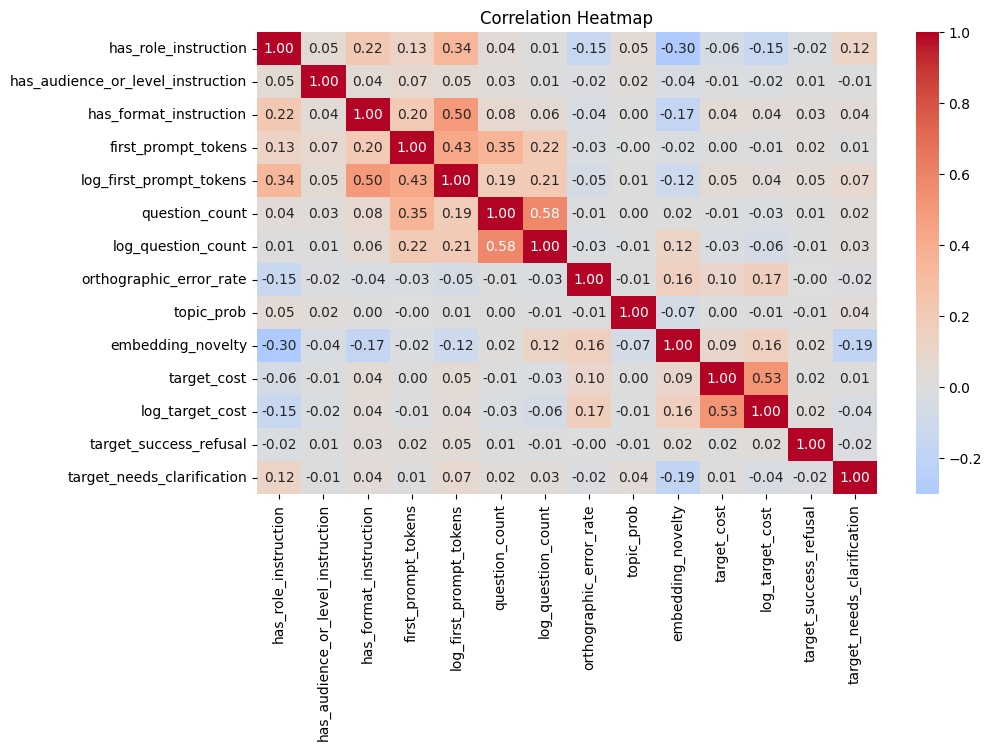

In [10]:
# ----------------------------
# CORRELATIONS
# ----------------------------

features_for_corr = binary_features + numeric_features + targets

corr = df[features_for_corr].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# Train test split

In [11]:
x_train_df, x_test_df, x_train_emb, x_test_emb = train_test_split(
    df,
    embeddings,
    test_size=0.2,
    random_state=42,
    stratify=df["target_success_refusal"]
)

# Feature selection

In [12]:
# features selection v01 - Structural prompt features

FEATURES_SELECTED_v01 = {
    "cat": [],
    "num": [
        "log_first_prompt_tokens",
        "log_question_count",
        "orthographic_error_rate",
    ],
    "bin": [
        "has_role_instruction",
        "has_audience_or_level_instruction",
        "has_format_instruction",
    ],
    "emb": []
}


# features selection v02 -  Structural + engineered semantic features
  
FEATURES_SELECTED_v02 = {
    "cat": [
        "task_type",
        "topic_cat",
    ],
    "num": [
        "log_first_prompt_tokens",
        "log_question_count",
        "embedding_novelty",
        "topic_prob",
        "orthographic_error_rate",
    ],
    "bin": [
        "has_role_instruction",
        "has_audience_or_level_instruction",
        "has_format_instruction",
    ],
    "emb": []
}


# features selection v03 - Structural + engineered semantic features + dense embeddings

embedding_cols = [
    f"embedding_{i}" for i in range(x_train_emb.shape[1])
]

df_emb_train = pd.DataFrame(
    x_train_emb,
    columns=embedding_cols,
    index=x_train_df.index
)

df_emb_test = pd.DataFrame(
    x_test_emb,
    columns=embedding_cols,
    index=x_test_df.index
)

x_train_full = pd.concat(
    [x_train_df, df_emb_train],
    axis=1
)

x_test_full = pd.concat(
    [x_test_df, df_emb_test],
    axis=1
)

FEATURES_SELECTED_v03 = {
    "cat": [
        "task_type",
        "topic_cat",
    ],
    "num": [
        "log_first_prompt_tokens",
        "log_question_count",
        "embedding_novelty",
        "topic_prob",
        "orthographic_error_rate",
    ],
    "bin": [
        "has_role_instruction",
        "has_audience_or_level_instruction",
        "has_format_instruction",
    ],
    "emb": embedding_cols
}

FEATURES_SELECTIONS = {
    "v01": FEATURES_SELECTED_v01,
    "v02": FEATURES_SELECTED_v02,
    "v03": FEATURES_SELECTED_v03,
}

# drop: question_count, total_turns, interaction_rounds, total_user_tokens, total_assistant_tokens, total_tokens, log_total_tokens

# Logistic regression modell "target_success_refusal"

In [13]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for version, features in FEATURES_SELECTIONS.items():

    features_cols = (
        features.get("cat", [])
        + features.get("num", [])
        + features.get("bin", [])
        + features.get("emb", [])
    )
    
    # preprocess
    transformers = []

    if "num" in features:
        transformers.append(
            ("num", StandardScaler(), features["num"])
        )

    if "emb" in features:
        transformers.append(
            ("emb", StandardScaler(), features["emb"])
        )

    if "bin" in features:
        transformers.append(
            ("bin", "passthrough", features["bin"])
        )

    if "cat" in features:
        transformers.append(
            ("cat", OneHotEncoder(handle_unknown="ignore"), features["cat"])
        )

    preprocess = ColumnTransformer(
        transformers=transformers,
        remainder="drop"
    )  


    # model
    model_reg = LogisticRegression(max_iter=2000, class_weight="balanced") 

    # pipeline
    pipeline = Pipeline([
        ("preprocess", preprocess), 
        ("model", model_reg)
    ])

    results = cross_validate(
        pipeline,
        x_train_full[features_cols],
        x_train_df["target_success_refusal"],
        cv=cv,
        scoring=["roc_auc", "f1", "precision", "recall"]
    )

    print("##########")
    print(version)
    print(
        "ROC AUC:",
        results["test_roc_auc"].mean()
    )
    print(
        "F1:",
        results["test_f1"].mean()
    )

    print(
        "Precision:",
        results["test_precision"].mean()
    )

    print(
        "Recall:",
        results["test_recall"].mean()
    )

    # fit model

    if "emb" in features:
        x_train = x_train_full
        x_test = x_test_full
    else:
        x_train = x_train_df
        x_test = x_test_df

    pipeline.fit(
        x_train_full[features_cols],
        x_train_df["target_success_refusal"]
        )

    # predict test
    target_success_refusal_test_pred = pipeline.predict(
        x_test_full[features_cols]
    )

    target_success_refusal_test_proba = pipeline.predict_proba(
        x_test_full[features_cols]
    )[:, 1]

    # names of features

    model = pipeline.named_steps["model"]
    preprocess = pipeline.named_steps["preprocess"]

    feature_names = preprocess.get_feature_names_out()

    coefficients = model.coef_[0]

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients
    })

    coef_df = coef_df.sort_values("coefficient", ascending=False)


    # SHAP 

    features_train_transformed = preprocess.transform(x_train_full[features_cols])
    features_test_transformed = preprocess.transform(x_test_full[features_cols])

    explainer = shap.LinearExplainer(
    model,
    features_train_transformed
    )

    shap_values = explainer(features_test_transformed)


    fi_shap = pd.DataFrame({
        "feature": feature_names,
        "importance": np.abs(shap_values.values).mean(axis=0)
    }).sort_values("importance", ascending=False)

    def original_feature_name(feature):

        # numeric features
        for col in features["num"]:
            if feature == f"num__{col}":
                return col

        # binary features
        for col in features["bin"]:
            if feature == f"bin__{col}":
                return col

        # categorical features (OHE)
        for col in features["cat"]:
            if feature.startswith(f"cat__{col}_"):
                return col

        # embeddings
        for col in features.get("emb", []):
            if feature.startswith(f"emb__{col}"):
                return "embeddings"

        return feature


    fi_shap["original_feature"] = (
        fi_shap["feature"]
        .apply(original_feature_name)
    )

    grouped_importance = (
        fi_shap.groupby("original_feature", as_index=False)["importance"]
               .mean()
            .sort_values("importance", ascending=False)
    )
 

    # metrics
    print("##########")
    print(version)
    print("##########")
    print("ROC AUC:", roc_auc_score(x_test_df["target_success_refusal"], target_success_refusal_test_proba))
    print("f1_score:", f1_score(x_test_df["target_success_refusal"], target_success_refusal_test_pred))
    print("Precision:", precision_score(x_test_df["target_success_refusal"], target_success_refusal_test_pred))
    print("Recall:", recall_score(x_test_df["target_success_refusal"], target_success_refusal_test_pred))
    print(coef_df.head(40))
    print(grouped_importance)

##########
v01
ROC AUC: 0.5909374152999901
F1: 0.656255757412422
Precision: 0.9695469443482185
Recall: 0.4960411713730134
##########
v01
##########
ROC AUC: 0.5925234202640851
f1_score: 0.6546318995616968
Precision: 0.966864165020847
Recall: 0.4948337825696316
                                  feature  coefficient
0            num__log_first_prompt_tokens         0.37
4  bin__has_audience_or_level_instruction         0.25
5             bin__has_format_instruction         0.03
2            num__orthographic_error_rate        -0.02
1                 num__log_question_count        -0.11
3               bin__has_role_instruction        -0.64
                    original_feature  importance
3            log_first_prompt_tokens        0.30
2               has_role_instruction        0.18
4                 log_question_count        0.09
5            orthographic_error_rate        0.02
1             has_format_instruction        0.01
0  has_audience_or_level_instruction        0.00
##########


In [14]:
# check  "has_role_instruction"

''' pd.crosstab(
    df["has_role_instruction"],
    df["target_success_refusal"],
    normalize="index"
)

pd.crosstab(
    df["has_role_instruction"],
    df["target_success_refusal"]
)

pd.crosstab(
    df["task_type"],
    df["has_role_instruction"],
    normalize="index"
)

pd.crosstab(
    [
        df["task_type"],
        df["has_role_instruction"]
    ],
    df["target_success_refusal"],
    normalize="index"
) '''

# Although role instructions showed a negative coefficient in the logistic regression model, further analysis revealed that this effect is largely explained by their 
# strong association with specific task types, particularly roleplay. When controlling for task type, the relationship between role instructions and refusal probability 
# becomes inconsistent and relatively small. Therefore, role instructions should be interpreted as a contextual indicator rather than an independent predictor.

' pd.crosstab(\n    df["has_role_instruction"],\n    df["target_success_refusal"],\n    normalize="index"\n)\n\npd.crosstab(\n    df["has_role_instruction"],\n    df["target_success_refusal"]\n)\n\npd.crosstab(\n    df["task_type"],\n    df["has_role_instruction"],\n    normalize="index"\n)\n\npd.crosstab(\n    [\n        df["task_type"],\n        df["has_role_instruction"]\n    ],\n    df["target_success_refusal"],\n    normalize="index"\n) '

# Analysis Summary

## Objective
Predict whether an LLM response contains a refusal pattern based on prompt characteristics.

## Defined target
```python
refusal_pattern = r"(?i)(i can't|i cannot|i’m sorry|i am sorry|as an ai|i do not have access)"

df["target_success_refusal"] = (
    ~df["first_response"].fillna("").str.contains(refusal_pattern, regex=True)
).astype(int)
```


## Approach
Three feature sets were evaluated:

- v01: structural prompt features
- v02: structural + semantic metadata
- v03: structural + semantic features + embeddings

Models were evaluated using stratified 5-fold cross-validation and a final holdout test set.

## Key Result

Adding embeddings substantially improved prediction performance:

| Model | ROC AUC | F1 |
|---|---:|---:|
| v01 | 0.59 | 0.65 |
| v02 | 0.63 | 0.69 |
| v03 | 0.73 | 0.83 |

The analysis shows that the ability to predict a refusal pattern in LLM responses gradually improves as additional types of information are incorporated into the model. While v01 considers only structural prompt features, v02 adds semantic metadata and already achieves better performance. v03 yields by far the greatest improvement, as it additionally integrates embeddings that appear to capture relevant semantic information about the prompt. Overall, this results in a noticeable improvement in both the model's discriminatory power and the quality of the classification of "refusal" responses.

# Linear regression modell "log_target_cost"

In [27]:
best_pipelines = {}
best_alphas = {}
best_scores = {}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
alphas = [0.1, 1, 10, 100]

for version, features in FEATURES_SELECTIONS.items():
    features_cols = (
        features.get("cat", [])
        + features.get("num", [])
        + features.get("bin", [])
        + features.get("emb", [])
    )

    transformers = []
    if features.get("num", []):
        transformers.append(("num", StandardScaler(), features["num"]))
    if features.get("emb", []):
        transformers.append(("emb", StandardScaler(), features["emb"]))
    if features.get("bin", []):
        transformers.append(("bin", "passthrough", features["bin"]))
    if features.get("cat", []):
        transformers.append(("cat", OneHotEncoder(handle_unknown="ignore"), features["cat"]))


    # preprocess
    
    preprocess = ColumnTransformer(transformers=transformers)

    best_r2 = -np.inf
    best_alpha = None
    best_pipeline = None

    for alpha in alphas:
        pipeline = Pipeline([
            ("preprocess", preprocess),
            ("model", Ridge(alpha=alpha))
        ])

        results = cross_validate(
            pipeline,
            x_train_full[features_cols],
            x_train_df["log_target_cost"],
            cv=cv,
            scoring=["r2", "neg_mean_absolute_error"]
        )

        mean_r2 = results["test_r2"].mean()

        print("##########")
        print(version, "alpha:", alpha, "R²:", mean_r2)

        if mean_r2 > best_r2:
            best_r2 = mean_r2
            best_alpha = alpha
            best_pipeline = pipeline


    # fit model with best alpha
    best_pipeline.fit(x_train_full[features_cols], x_train_df["log_target_cost"])
    best_pipelines[version] = best_pipeline
    best_alphas[version] = best_alpha
    best_scores[version] = best_r2

    print("################")
    print(version)
    print("Best alpha:", best_alpha)
    print("Best CV R²:", best_r2)

for version in ["v01", "v02", "v03"]:
    features = FEATURES_SELECTIONS[version]
    features_cols = (
        features.get("cat", [])
        + features.get("num", [])
        + features.get("bin", [])
        + features.get("emb", [])
    )

    pipeline = best_pipelines[version]
    model = pipeline.named_steps["model"]
    preprocess = pipeline.named_steps["preprocess"]
    feature_names = preprocess.get_feature_names_out()

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": model.coef_
    }).sort_values("coefficient", ascending=False)

    features_train_transformed = preprocess.transform(x_train_full[features_cols])
    features_test_transformed = preprocess.transform(x_test_full[features_cols])

    explainer = shap.LinearExplainer(model, features_train_transformed)
    shap_values = explainer(features_test_transformed)

    fi_shap = pd.DataFrame({
        "feature": feature_names,
        "importance": np.abs(shap_values.values).mean(axis=0)
    }).sort_values("importance", ascending=False)

    def original_feature_name(feature):
        for col in features.get("num", []):
            if feature == f"num__{col}":
                return col
        for col in features.get("bin", []):
            if feature == f"bin__{col}":
                return col
        for col in features.get("cat", []):
            if feature.startswith(f"cat__{col}_"):
                return col
        for col in features.get("emb", []):
            if feature == f"emb__{col}":
                return "embeddings"
        return feature

    fi_shap["original_feature"] = fi_shap["feature"].apply(original_feature_name)
    grouped_importance = (
        fi_shap.groupby("original_feature", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
    )

    print("##########")
    print(version)
    print("##########")
    display(coef_df.head(40))
    display(grouped_importance)

##########
v01 alpha: 0.1 R²: 0.06026221814015387
##########
v01 alpha: 1 R²: 0.06026256626991296
##########
v01 alpha: 10 R²: 0.06026488745610581
##########
v01 alpha: 100 R²: 0.060228012341806636
################
v01
Best alpha: 10
Best CV R²: 0.06026488745610581
##########
v02 alpha: 0.1 R²: 0.11904049555067753
##########
v02 alpha: 1 R²: 0.11904122213223453
##########
v02 alpha: 10 R²: 0.11904707921880564
##########
v02 alpha: 100 R²: 0.11901318470953803
################
v02
Best alpha: 10
Best CV R²: 0.11904707921880564
##########
v03 alpha: 0.1 R²: 0.3248125975314363
##########
v03 alpha: 1 R²: 0.32481724129030354
##########
v03 alpha: 10 R²: 0.3248591859070384
##########
v03 alpha: 100 R²: 0.3250621451859888
################
v03
Best alpha: 100
Best CV R²: 0.3250621451859888
##########
v01
##########


,feature,coefficient
2,num__orthographic_error_rate,0.16
0,num__log_first_prompt_tokens,0.11
5,bin__has_format_instruction,0.07
1,num__log_question_count,-0.08
4,bin__has_audience_or_level_instruction,-0.23
3,bin__has_role_instruction,-0.47


,original_feature,importance
2,has_role_instruction,0.13
5,orthographic_error_rate,0.12
3,log_first_prompt_tokens,0.08
4,log_question_count,0.06
1,has_format_instruction,0.03
0,has_audience_or_level_instruction,0.00


##########
v02
##########


,feature,coefficient
9,cat__task_type_coding,0.33
20,cat__topic_cat_technical,0.27
15,cat__task_type_translation,0.20
2,num__embedding_novelty,0.12
16,cat__task_type_writing_generation,0.11
7,bin__has_format_instruction,0.11
4,num__orthographic_error_rate,0.11
10,cat__task_type_email_writing,0.05
17,cat__topic_cat_domain,0.04
0,num__log_first_prompt_tokens,0.03


,original_feature,importance
7,task_type,0.27
8,topic_cat,0.18
0,embedding_novelty,0.10
3,has_role_instruction,0.10
6,orthographic_error_rate,0.08
5,log_question_count,0.06
2,has_format_instruction,0.04
4,log_first_prompt_tokens,0.02
9,topic_prob,0.02
1,has_audience_or_level_instruction,0.00


##########
v03
##########


,feature,coefficient
399,cat__task_type_translation,0.23
404,cat__topic_cat_technical,0.20
324,emb__embedding_319,0.16
393,cat__task_type_coding,0.14
0,num__log_first_prompt_tokens,0.10
400,cat__task_type_writing_generation,0.08
394,cat__task_type_email_writing,0.08
203,emb__embedding_198,0.07
227,emb__embedding_222,0.07
249,emb__embedding_244,0.07


,original_feature,importance
1,embeddings,7.05
8,task_type,0.16
9,topic_cat,0.09
5,log_first_prompt_tokens,0.08
7,orthographic_error_rate,0.05
6,log_question_count,0.02
4,has_role_instruction,0.02
10,topic_prob,0.01
3,has_format_instruction,0.01
0,embedding_novelty,0.01


# Analysis Summary

## Objective
Predict how much costs are influenced by prompt characteristics.

## Defined Target
```python
log_target_cost = log(first_response_tokens)
```
## Approach
Three feature sets were evaluated:

- v01: structural prompt features
- v02: structural + semantic metadata
- v03: structural + semantic features + embeddings

Models were evaluated using stratified 5-fold cross-validation and a final holdout test set.

## Key Result

Adding embeddings substantially improved prediction performance:

| Model | r2 Score | alpha |
|---|---:|---:|
| v01 | 0.06 | 10 |
| v02 | 0.12 | 10 |
| v03 | 0.33 | 100 |

The results show a stepwise pattern: In v01, the target values are primarily explained by structural prompt features, particularly by indicators of prompt length, spelling errors, and the presence of role instructions. In v02, this picture is expanded to include content-related features such as `task_type` and `topic_cat`, which provide additional explanatory power. v03 also incorporates embeddings that, as a group, make the strongest contribution, thereby indicating that semantic information related to log_target_cost is relevant, even though this effect is distributed across many individual dimension coefficients.